In [8]:
import json
import matplotlib.pyplot as plt

In [24]:
# load the dataset
file_path = '../../data/squad/raw/train-v1.1.json'
with open(file_path, 'r') as f:
    squad_data = json.load(f)

print('Number of articles:', len(squad_data['data']))

article = squad_data['data'][0]

print(article['title'])
print('Number of paragraphs:', len(article['paragraphs']))

paragraph = article['paragraphs'][0]
print('Number of Q&A pairs:', len(paragraph['qas']))

context = paragraph['context']
print('context:', context)

qas = paragraph['qas'][0]
print('Question:', qas['question'])

answer = qas['answers'][0]
print('Answers:', answer)

answer_start = answer['answer_start']
answer_len = len(answer['text'])
print(context[answer_start:answer_start + answer_len])

Number of articles: 442
University_of_Notre_Dame
Number of paragraphs: 55
Number of Q&A pairs: 5
context: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.
Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answers: {'answer_start': 515, 'text': 'Saint Bernadette Soubirous'}
Saint Bernadette Soubirous


In [25]:
paragraph_lengths = {}

for article in squad_data['data']:
    title = article['title']
    for paragraph in article['paragraphs']:
        context = paragraph['context']
        paragraph_lengths.setdefault(title, []).append(len(context))

number_of_paragraphs_per_title = []
lengths = []
for title, paragraphs_len in paragraph_lengths.items():
    #print(f"{title}: {len(paragraphs_len)} paragraphs, average size: {sum(paragraphs_len) / len(paragraphs_len):.2f} characters")
    number_of_paragraphs_per_title.append(len(paragraphs_len))
    lengths.extend(paragraphs_len)

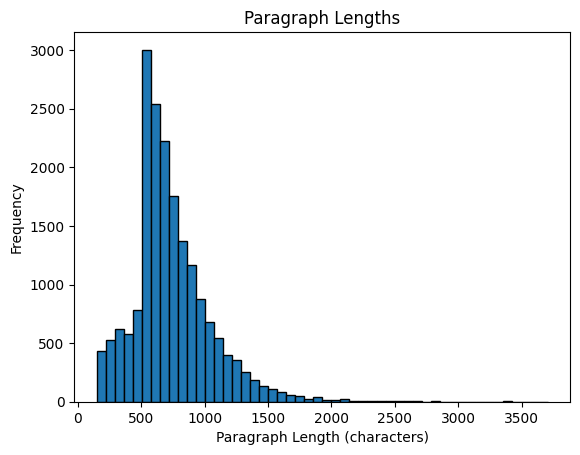

In [26]:
plt.hist(lengths, bins=50, edgecolor='black')
plt.xlabel('Paragraph Length (characters)')
plt.ylabel('Frequency')
plt.title('Paragraph Lengths')
plt.show()

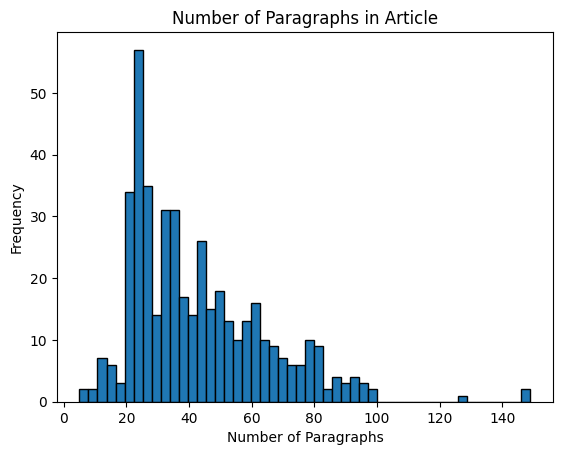

In [27]:
plt.hist(number_of_paragraphs_per_title, bins=50, edgecolor='black')
plt.xlabel('Number of Paragraphs')
plt.ylabel('Frequency')
plt.title('Number of Paragraphs in Article')
plt.show()